# Application Programming Interface

Det er mulig aksessere en webside eller database gjennom et Application Programming Interface (API). Deretter foreta et API-kall med en forespørsel, eller en 'query'.

Et API muliggjør kommunikasjon mellom servere.

### Fordelen med API

Med API kan du lage spørringer som henter oppdaterte tall. API gjør det lettere å hente tall for videre analyse.

Det er mer fleksibelt og mer avansert enn å laste ned data fra et brukergrensensittet bestemt av den som har laget nettsiden.

Det er lettere å tilpasse akkurat de data du trenger, og så lenge det er kontakt mellom deg (klient) og nettstedet (server) har du tilgang til dataene uten å måtte lagre lokalt.

## Video: Finne API-endpoint

Denne videoen viser hvordan man finner fram til et API-endepunkt

<iframe
    width="560"
    height="315"
    src="https://www.youtube.com/embed/bq9nSWfIYCE"
``
    frameborder="0"
    allowfullscreen>
</iframe>

### REST API

En Representational State Transfer ([REST](https://en.wikipedia.org/wiki/REST)) er en programvare-arkitektur som definerer kommunikasjon i et nettverk mellom *client* og *server* i et nettverk. Kommunikasjonen skjer gjennom et regelverk; hypertekstoverføringsprotokoll, Hyper Text Transfer Protocol (HTTP).

Forespørsler skjer gjennom `request` biblioteket som lar deg benytte en hypertekstoverføringsprotokoll i python miljøet.

Pythons [requests](https://pypi.org/project/requests/) er et brukervennlig bibliotek som 
tilgjengelig for intallasjon på Pypi:

$ python -m pip install requests

Metoden `.get()` brukes til en HTTP GET-forespørsel fra nettleseren din (klienten) til serveren gjennom nettstedets URL-adresse. Nettstedet gir et respons gjennom en statuskode. Kode 200 betyr at siden eksisterer og fungerer. Ethvert nettsted vi prøver å aksessere vil gi oss en statuskode:

In [1]:
import requests
api_url = "https://usn.no"
response = requests.get(api_url)
print(response.status_code)


200


Satus kode 200 vil si at siden eksisterer og vi har kontakt. Alt ligger til rette for å dele data mellom deg (klienten) og nettstedet (server).

### Javascript Object Notation

Standard formatet for overføring av tekst i nettverk er Javascript Object Notation (JSON). Det er lett å forstå både for mennesker og maskiner og er filformatet som brukes i databaser og API. JSON lagrer data i nøkkel-verdi par, ikke ulikt python dictionary, som en samling dataelementer av forskjellig datatype, der datene indekseres med nøkkel i form av en tekststreng. Se ressursiden til *Python for realfag* [TechTeach](https://techteach.no/python/), oppgave [3.11](https://techteach.no/python/files/pannekaker.py).

JSON nøkkel er alltid et string objekt, innelukket i en krøllparantes og alltid med dobbelt anførselstegn `"`. Verdiene som korresponderer til nøkkelen kan være hvilken som helst [data type](https://www.geeksforgeeks.org/python/python-data-types/), nøstet JSON, eller andre sekvens data.


For å lese JSON i python bruker vi python-bibliotekt [`json`](https://www.geeksforgeeks.org/python/python-json/)

In [2]:
import json
s = '{"language": "Python", "version": 3.11}'
d = json.loads(s)
print(d)

{'language': 'Python', 'version': 3.11}


json biblioteket muliggjør konvertering til [python dictionary](https://www.geeksforgeeks.org/python/difference-between-json-and-dictionary-in-python/):

In [3]:
import json

emp = '{"id":"09", "name": "Nitin", "department":"Finance"}'
print("This is JSON", type(emp), emp)

print("Now convert from JSON to Python")
d = json.loads(emp)
print("Converted to Python", type(d))
print(d)

This is JSON <class 'str'> {"id":"09", "name": "Nitin", "department":"Finance"}
Now convert from JSON to Python
Converted to Python <class 'dict'>
{'id': '09', 'name': 'Nitin', 'department': 'Finance'}


### API endepunkt

Også når vi aksesserer apiet får vi gyldig status, fordi vi klarer å oppnå kontakt med nettstedet. Men vi får feilmelidng fordi nettstedet ikke inneholder `.json()`. Det er derimor en html side. Selv om vi skriver inn 
```python
"https://data.ssb.no/api"
```
har vi ikke fått kontakt med datatabeller i `.json` fil men med en `html`-side.

In [4]:
import requests
api_url = "https://data.ssb.no/api"
response = requests.get(api_url)
print(response.status_code)
#print(response.json())

import traceback

response = requests.get("https://data.ssb.no/api")

try:
    data = response.json()
except Exception:
    print('Feilemelding:',traceback.format_exc().splitlines()[-1])

print(response.headers["Content-Type"]) 

200
Feilemelding: requests.exceptions.JSONDecodeError: Expecting value: line 1 column 1 (char 0)
text/html;charset=utf-8


For å få kontakt med den informasjonen API-et inneholder må vi nå endepunktsURL (endpoint). Nettstedet [Data.norge.no](https://data.norge.no/nb/about) har oversikt over data fra norsk offentlig sektor, med en egen datakatalog over API-er

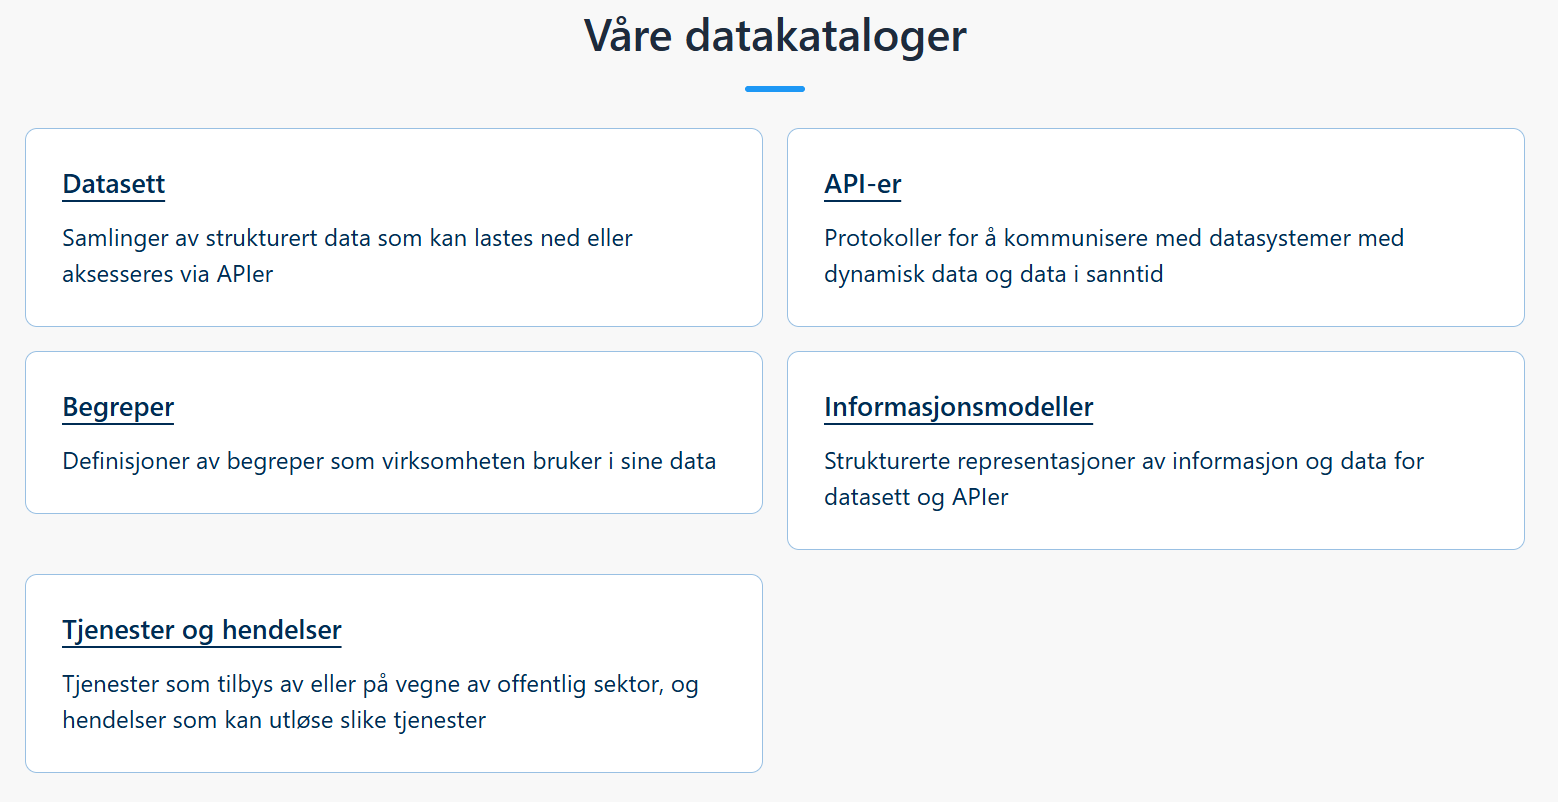

In [5]:
# TEST CELL
from IPython.display import Image

Image("../images/dataNorge.png", width=500, height=400)

Alle API-ene i katalogen følger standard for beskrivelse av datasett, datatjenester og datakataloger ([DCAT-AP-NO](https://data.norge.no/specification/dcat-ap-no)) der endepunktsURL er standardinformasjon.
```note
En datatjeneste

SKAL alltid beskrives med opplysninger om utgiveren av datatjenesten og kontaktpunkt, samt tittel og endepunktsURL til datatjenesten
```

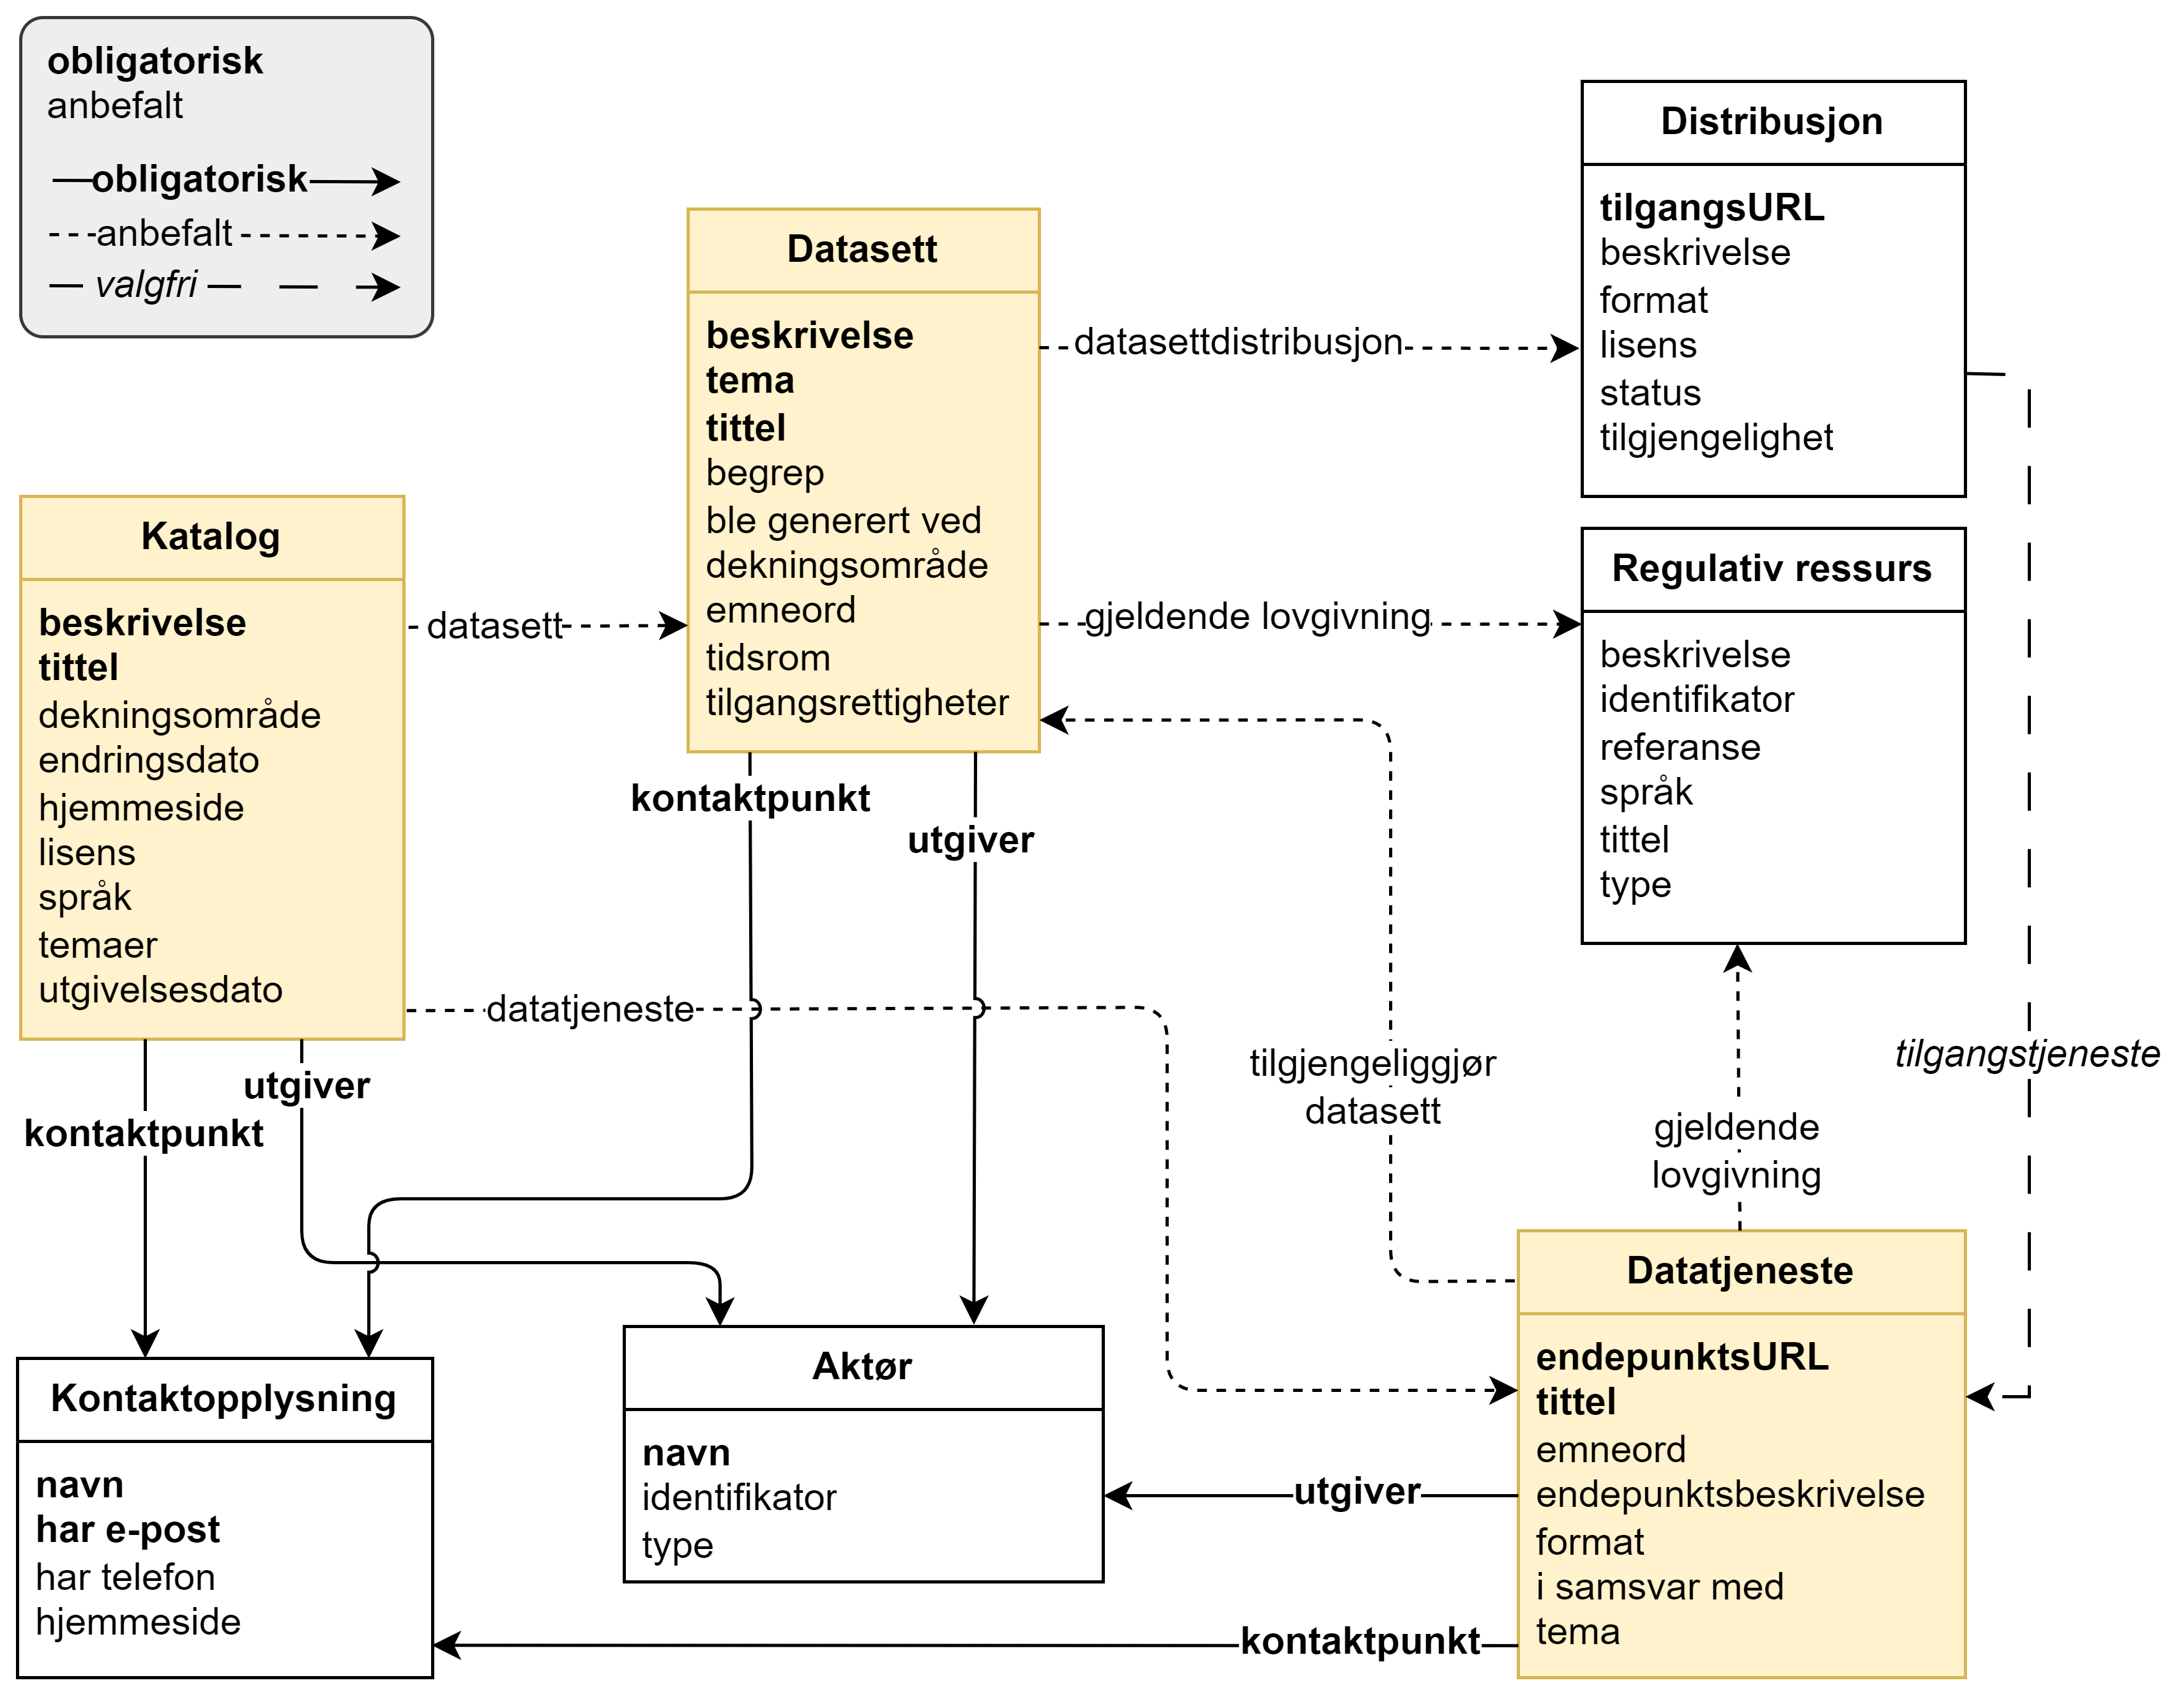

In [6]:
# TEST CELL
from IPython.display import Image

Image("../images/DCAT-AP-NO.png", width=500, height=400)

Et søk etter [statistikkbanken](https://data.norge.no/nb/data-services/4c525f0a-f10d-3bcc-a67e-ee3fbbfd6ccc/api-lag-egne-datasett-fra-ssbs-statistikkbank-pxwebapi?tab=overview) her gir endepunktsURL til datatabeller

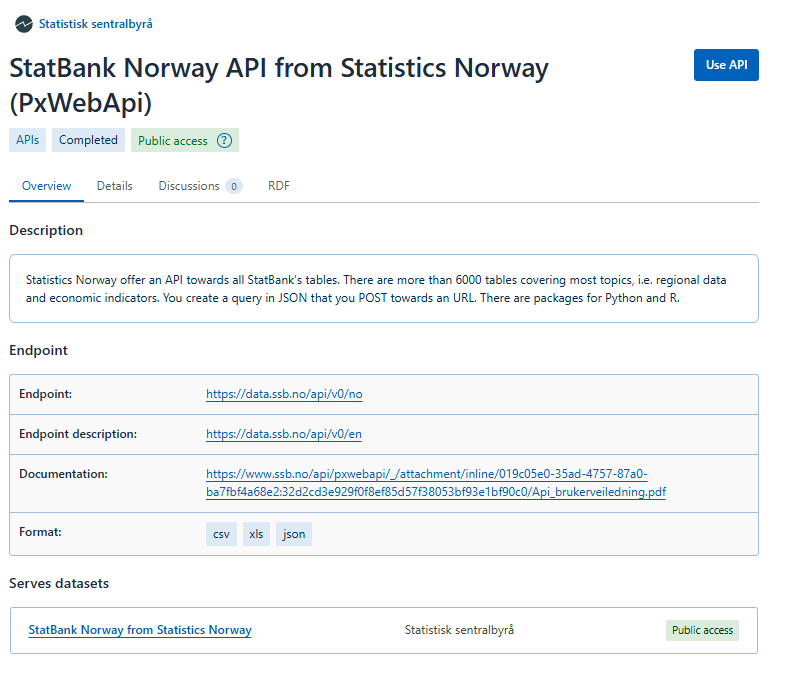

In [7]:
# TEST CELL
from IPython.display import Image

Image("../images/SSB_endpoint.png", width=500, height=400)

### Open API

[OpenAPI](https://swagger.io/docs/specification/v3_0/about/) er en standardisert beskrivelse av et API, som kommer med en egen [dokumentasjon](https://swagger.io/specification/v3.2/#openapi-description-structure) Swagger UI er et verktøy som viser denne beskrivelsen som en interaktiv nettside. På [SSB's swagger](https://data.ssb.no/api/pxwebapi/v2/index.html) kan man teste ut forskjellige `.get`forespørsler. En blank forespørsel gir endpunktsURL for alle tabeller.
```python
https://data.ssb.no/api/pxwebapi/v2/tables
```


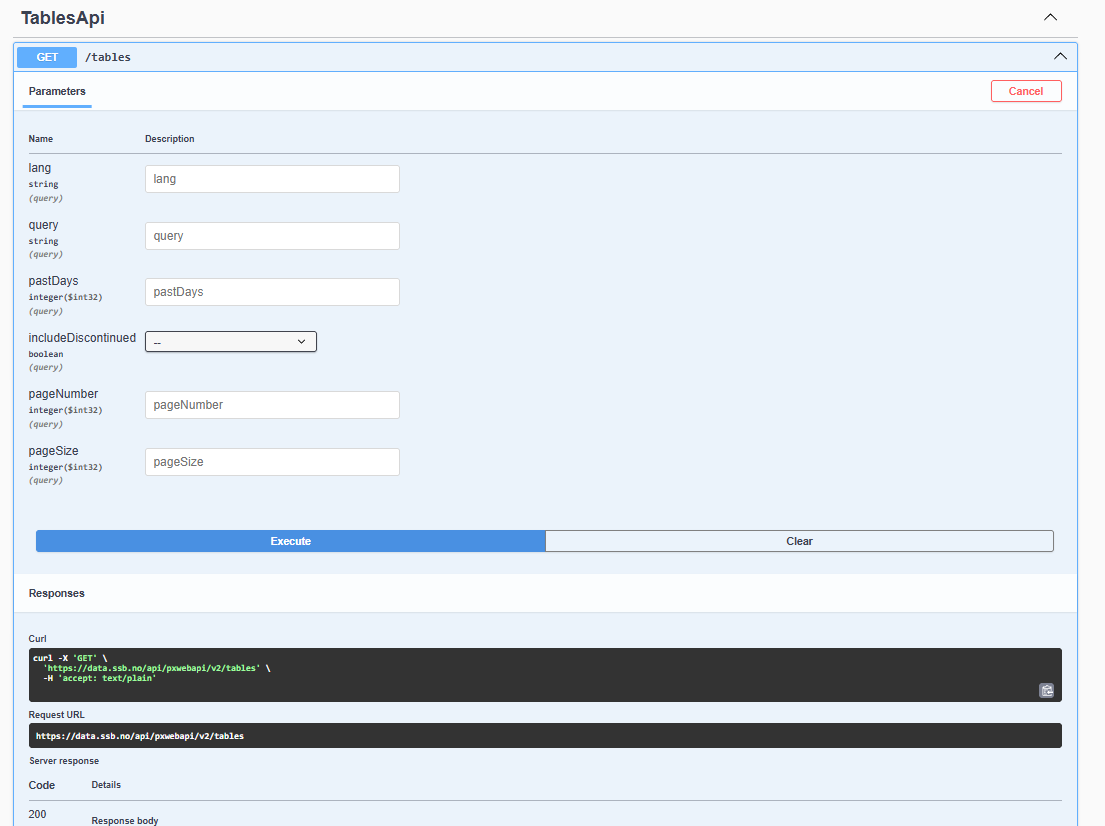

In [8]:
from IPython.display import Image

Image("../images/swagger.png", width=500, height=400)

## Video: Lage API-query

Denne videoen viser hvordan man lager et API-query

<iframe
    width="560"
    height="315"
    src="https://www.youtube.com/embed/a0HU2mpkbNc"
``
    frameborder="0"
    allowfullscreen>
</iframe>

In [9]:
import requests
api_url = "https://data.ssb.no/api/v0/no"
response = requests.get(api_url)
print(response.status_code)
print(response.json())

200
[{'dbid': 'table', 'text': 'Statistikkbanken etter emne'}]


Med pandas kan man få ut tabellen som en lesbar 'dataframe', som i dette tilfellet er tabellen over tabeller:

In [10]:
import pandas as pd
import requests

api_url = "https://data.ssb.no/api/v0/no/table"

response = requests.get(api_url)

df = pd.DataFrame(response.json())
print(df.head())

   id type                            text
0  al    l                  Arbeid og lønn
1  bf    l            Bank og finansmarked
2  vf    l  Bedrifter, foretak og regnskap
3  be    l                      Befolkning
4  bb    l          Bygg, bolig og eiendom


In [11]:
import requests
api_url = "https://data.ssb.no/api/v0/no/table/08307"
response = requests.get(api_url)

print(response.json())

{'title': '08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter statistikkvariabel og år', 'variables': [{'code': 'ContentsCode', 'text': 'statistikkvariabel', 'values': ['ProdTotal', 'VannKraft', 'VindKraft', 'Solkraft', 'VarmeKraft', 'Import', 'Eksport', 'Bruttoforbruk', 'ForbrukKraftStasj', 'Pumpekraftforbruk', 'TapStatistDiff', 'Nettoforbruk'], 'valueTexts': ['Produksjon i alt', 'Vannkraftproduksjon', 'Vindkraftproduksjon', 'Solkraftproduksjon', 'Varmekraftproduksjon', 'Import', 'Eksport', 'Bruttoforbruk', 'Forbruk i kraftstasjonene (-2019)', 'Pumpekraftforbruk', 'Tap og statistisk differanse', 'Nettoforbruk']}, {'code': 'Tid', 'text': 'år', 'values': ['1950', '1955', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996'

Metoden .json() gir oss innholdet i repsonsen. Dette er metadata som gir data om dataen.

In [12]:
metadata = response.json()
print(metadata)

{'title': '08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter statistikkvariabel og år', 'variables': [{'code': 'ContentsCode', 'text': 'statistikkvariabel', 'values': ['ProdTotal', 'VannKraft', 'VindKraft', 'Solkraft', 'VarmeKraft', 'Import', 'Eksport', 'Bruttoforbruk', 'ForbrukKraftStasj', 'Pumpekraftforbruk', 'TapStatistDiff', 'Nettoforbruk'], 'valueTexts': ['Produksjon i alt', 'Vannkraftproduksjon', 'Vindkraftproduksjon', 'Solkraftproduksjon', 'Varmekraftproduksjon', 'Import', 'Eksport', 'Bruttoforbruk', 'Forbruk i kraftstasjonene (-2019)', 'Pumpekraftforbruk', 'Tap og statistisk differanse', 'Nettoforbruk']}, {'code': 'Tid', 'text': 'år', 'values': ['1950', '1955', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996'

### Lager spørring (query)

Vi definerer en spørring `query` i form av en liste ( [ ] ) og bestemmer hvordan vi vil ha svaret `response` i form av en dictionary ( { } ). 

```python
query = {
    "query": [
        {
            "code": "ContentsCode",
            "selection": {
                "filter": "item",
                "values": ["VindKraft", "Solkraft"]
            }
        },
        {
            "code": "Tid",
            "selection": {
                "filter": "all",
                "values": ["*"]
            }
        }
    ],
    "response": {
        "format": "json-stat2"
    }
}
```

In [13]:
import requests

url = "https://data.ssb.no/api/v0/no/table/08307"

query = {
    "query": [
        {
            "code": "ContentsCode",
            "selection": {
                "filter": "item",
                "values": ["VindKraft", "Solkraft"]
            }
        },
        {
            "code": "Tid",
            "selection": {
                "filter": "item",
                #'filter': 'all',
                "values": ['2021','2022','2023',"2024", "2025"]
                #'values':['*']
            }
        }
    ],
    "response": {
        "format": "json-stat2"
    }
}

response = requests.post(url, json=query)
data = response.json()
print(response.status_code)
print(data)

200
{'version': '2.0', 'class': 'dataset', 'label': '08307: Produksjon, import, eksport og forbruk av elektrisk kraft (GWh), etter statistikkvariabel og år', 'source': 'Statistisk sentralbyrå', 'updated': '2026-05-08T06:00:00Z', 'role': {'time': ['Tid'], 'metric': ['ContentsCode']}, 'id': ['ContentsCode', 'Tid'], 'size': [2, 5], 'dimension': {'ContentsCode': {'label': 'statistikkvariabel', 'category': {'index': {'VindKraft': 0, 'Solkraft': 1}, 'label': {'VindKraft': 'Vindkraftproduksjon', 'Solkraft': 'Solkraftproduksjon'}, 'unit': {'VindKraft': {'base': 'GWh', 'decimals': 0}, 'Solkraft': {'base': 'GWh', 'decimals': 0}}}, 'extension': {'elimination': False, 'refperiod': {'VindKraft': 'Hele kalenderåret', 'Solkraft': 'Hele kalenderåret'}, 'show': 'value', 'measuringType': {'VindKraft': 'Flow', 'Solkraft': 'Flow'}, 'priceType': {'VindKraft': 'NotApplicable', 'Solkraft': 'NotApplicable'}, 'adjustment': {'VindKraft': 'None', 'Solkraft': 'None'}}}, 'Tid': {'label': 'år', 'category': {'index'

Biblioteket pyjstat lager om til `dataframe`, som vi kan burke DateTimeIndex på.

In [14]:
from pyjstat import pyjstat

dataset = pyjstat.Dataset.read(response.text)

df = dataset.write('dataframe')

print(df)

    statistikkvariabel    år  value
0  Vindkraftproduksjon  2021  11768
1  Vindkraftproduksjon  2022  14810
2  Vindkraftproduksjon  2023  13965
3  Vindkraftproduksjon  2024  14545
4  Vindkraftproduksjon  2025  13899
5   Solkraftproduksjon  2021     33
6   Solkraftproduksjon  2022     63
7   Solkraftproduksjon  2023    165
8   Solkraftproduksjon  2024    251
9   Solkraftproduksjon  2025    348


In [15]:
df = df.pivot(
    index="år",
    columns="statistikkvariabel",
    values="value"
)
print(df)

statistikkvariabel  Solkraftproduksjon  Vindkraftproduksjon
år                                                         
2021                                33                11768
2022                                63                14810
2023                               165                13965
2024                               251                14545
2025                               348                13899


In [16]:
df

statistikkvariabel,Solkraftproduksjon,Vindkraftproduksjon
år,,
2021,33,11768
2022,63,14810
2023,165,13965
2024,251,14545
2025,348,13899


<Axes: xlabel='år'>

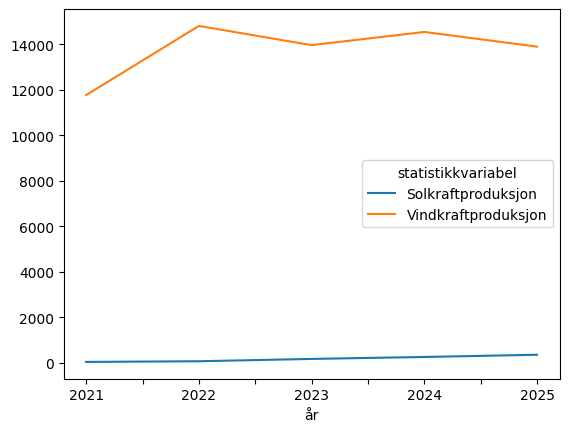

In [17]:
import matplotlib.pyplot as plt
df.plot()

I metadataen ser vi verider 

In [18]:
type(metadata)

dict

In [19]:
print(list(metadata.keys()))

['title', 'variables']


In [20]:
type(metadata['title'])

str

In [21]:
type(metadata['variables'])

list

In [22]:
print(metadata["variables"][0])
print(metadata["variables"][1])

{'code': 'ContentsCode', 'text': 'statistikkvariabel', 'values': ['ProdTotal', 'VannKraft', 'VindKraft', 'Solkraft', 'VarmeKraft', 'Import', 'Eksport', 'Bruttoforbruk', 'ForbrukKraftStasj', 'Pumpekraftforbruk', 'TapStatistDiff', 'Nettoforbruk'], 'valueTexts': ['Produksjon i alt', 'Vannkraftproduksjon', 'Vindkraftproduksjon', 'Solkraftproduksjon', 'Varmekraftproduksjon', 'Import', 'Eksport', 'Bruttoforbruk', 'Forbruk i kraftstasjonene (-2019)', 'Pumpekraftforbruk', 'Tap og statistisk differanse', 'Nettoforbruk']}
{'code': 'Tid', 'text': 'år', 'values': ['1950', '1955', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '

In [23]:
print(metadata["variables"][0].keys())
print(metadata["variables"][1].keys())

dict_keys(['code', 'text', 'values', 'valueTexts'])
dict_keys(['code', 'text', 'values', 'valueTexts', 'time'])


In [24]:
for var in metadata["variables"]:
    print(f"\nKode: {var['code']}")
    print(f"Tekst: {var['text']}")
    print(f"Antall verdier: {len(var['values'])}")


Kode: ContentsCode
Tekst: statistikkvariabel
Antall verdier: 12

Kode: Tid
Tekst: år
Antall verdier: 68


In [25]:
filtre = {
    var["code"]: var["values"]
    for var in metadata["variables"]
    if var["code"] in ["ContentsCode", "Tid"]
}

print(filtre)

{'ContentsCode': ['ProdTotal', 'VannKraft', 'VindKraft', 'Solkraft', 'VarmeKraft', 'Import', 'Eksport', 'Bruttoforbruk', 'ForbrukKraftStasj', 'Pumpekraftforbruk', 'TapStatistDiff', 'Nettoforbruk'], 'Tid': ['1950', '1955', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']}
